# Binary Vertebra / Spine Premask Experiment

## Purpose
This notebook explores a binary segmentation setup as an auxiliary experiment.

## Scope
- binary target generation from existing image + ID mask pairs
- YOLO binary segmentation export
- training and evaluation
- inference on new JPEG images for premask generation

## Notes
- This is an experimental notebook.
- It is not the main multiclass training notebook.
- Paths must be configured in the setup section before running.

In [1]:
# =========================================================
# Section 1 — Setup, paths, and dataset discovery
# =========================================================

from pathlib import Path
import os
import json
import random
import shutil
import warnings
from datetime import datetime
from collections import Counter

import numpy as np
import pandas as pd

from PIL import Image
import cv2

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

plt.rcParams["figure.figsize"] = (14, 6)

print("Imports loaded.")

Imports loaded.


In [ ]:
# =========================================================
# Mount Google Drive and reuse existing project paths
# =========================================================

from google.colab import drive
drive.mount("/content/drive", force_remount=False)

CONFIG = {
    "seed": 42,

    "drive_mount_point": Path("/content/drive"),

    # Replace these three paths before running in Colab.
    
    "project_base": Path(
        " /content/drive/MyDrive/REPLACE_WITH_PROJECT_BASE "
    ),

    "dataset_root": Path(
        " /content/drive/MyDrive/REPLACE_WITH_DATASET_ROOT "
    ),

    "project_root": Path(
        " /content/drive/MyDrive/REPLACE_WITH_PROJECT_ROOT "
    ),

    "index_csv_name": "indice_dataset.csv",
    "class_dict_json_name": "diccionario_etiquetas_T1_T12_L1_L5.json",

    "corrected_multiclass_mask_rel_dir": "vertebra_mask_correction/outputs/LabelMultiClass_ID_PNG_corrected",
    "prefer_corrected_masks": True,

    # Keep your known ignore list from the uploaded notebook.
    "ignore_mask_stems": [
        "LabelMulti_S_137",
    ],

    # Binary target
    "background_id": 0,
    "binary_foreground_id": 1,

    # Visualization
    "num_visual_checks": 4,
}

random.seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])

PROJECT_BASE = CONFIG["project_base"]
DATASET_ROOT = CONFIG["dataset_root"]
PROJECT_ROOT = CONFIG["project_root"]

EXPORTS_ROOT = PROJECT_ROOT / "exports"
TRAINING_RUNS_ROOT = PROJECT_ROOT / "training_runs"
META_ROOT = PROJECT_ROOT / "meta"

for p in [PROJECT_ROOT, EXPORTS_ROOT, TRAINING_RUNS_ROOT, META_ROOT]:
    p.mkdir(parents=True, exist_ok=True)

INDEX_CSV_PATH = DATASET_ROOT / CONFIG["index_csv_name"]
CLASS_DICT_PATH = DATASET_ROOT / CONFIG["class_dict_json_name"]
CORRECTED_MULTICLASS_DIR = DATASET_ROOT / CONFIG["corrected_multiclass_mask_rel_dir"]

print("PROJECT_BASE       :", PROJECT_BASE)
print("DATASET_ROOT       :", DATASET_ROOT, "| exists:", DATASET_ROOT.exists())
print("PROJECT_ROOT       :", PROJECT_ROOT, "| exists:", PROJECT_ROOT.exists())
print("TRAINING_RUNS_ROOT :", TRAINING_RUNS_ROOT)
print("INDEX_CSV_PATH     :", INDEX_CSV_PATH, "| exists:", INDEX_CSV_PATH.exists())
print("CLASS_DICT_PATH    :", CLASS_DICT_PATH, "| exists:", CLASS_DICT_PATH.exists())
print("CORRECTED_MASK_DIR :", CORRECTED_MULTICLASS_DIR, "| exists:", CORRECTED_MULTICLASS_DIR.exists())

Mounted at /content/drive
PROJECT_BASE       : /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project
DATASET_ROOT       : /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/Scoliosis_Dataset | exists: True
PROJECT_ROOT       : /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg | exists: True
TRAINING_RUNS_ROOT : /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/training_runs
INDEX_CSV_PATH     : /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/Scoliosis_Dataset/indice_dataset.csv | exists: True
CLASS_DICT_PATH    : /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/v

In [3]:
# =========================================================
# Dataset folder checks
# =========================================================

required_dirs = [
    "Normal",
    "Scoliosis",
    "LabelMultiClass_ID_PNG",
]

optional_dirs = [
    "LabelBinaryJPG",
    "LabelMultiClass_Color_JPG",
    "LabelMultiClass_Gray_JPG",
    "RadiographMetrics",
    "vertebra_mask_correction/outputs/LabelMultiClass_ID_PNG_corrected",
]

print("Required folders:")
for rel in required_dirs:
    p = DATASET_ROOT / rel
    print(f"{rel:70s} -> {'OK' if p.exists() else 'MISSING'}")

print("\nOptional/reference folders:")
for rel in optional_dirs:
    p = DATASET_ROOT / rel
    print(f"{rel:70s} -> {'OK' if p.exists() else 'MISSING'}")

assert DATASET_ROOT.exists(), f"DATASET_ROOT does not exist: {DATASET_ROOT}"
assert INDEX_CSV_PATH.exists(), f"Missing indice_dataset.csv: {INDEX_CSV_PATH}"

Required folders:
Normal                                                                 -> OK
Scoliosis                                                              -> OK
LabelMultiClass_ID_PNG                                                 -> OK

Optional/reference folders:
LabelBinaryJPG                                                         -> OK
LabelMultiClass_Color_JPG                                              -> OK
LabelMultiClass_Gray_JPG                                               -> OK
RadiographMetrics                                                      -> OK
vertebra_mask_correction/outputs/LabelMultiClass_ID_PNG_corrected      -> OK


In [4]:
# =========================================================
# Load existing dataset index and class dictionary
# =========================================================

df_index = pd.read_csv(INDEX_CSV_PATH)

print("Index shape:", df_index.shape)
display(df_index.head())

required_columns = [
    "grupo",
    "imagen",
    "id_paciente",
    "ruta_radiografia",
    "ruta_mascara_binaria",
    "ruta_mascara_multiclase_id_png",
]

missing_required = [c for c in required_columns if c not in df_index.columns]
assert len(missing_required) == 0, f"Missing required columns: {missing_required}"

if CLASS_DICT_PATH.exists():
    with open(CLASS_DICT_PATH, "r", encoding="utf-8") as f:
        class_dict = json.load(f)

    multiclass_map = {
        int(k): v for k, v in class_dict["mascara_multiclase_id_png"].items()
    }

    print("\nMulticlass map:")
    for k in sorted(multiclass_map.keys()):
        print(f"{k:2d} -> {multiclass_map[k]}")
else:
    multiclass_map = {0: "background"}
    for i in range(1, 18):
        multiclass_map[i] = f"class_{i}"

print("\nRequired columns are present.")

Index shape: (250, 9)


,grupo,imagen,id_paciente,ruta_radiografia,ruta_mascara_binaria,ruta_mascara_multiclase_id_png,ruta_mascara_multiclase_grises_jpg,ruta_mascara_multiclase_color_jpg,metricas_json
0,Normal,N_1.jpg,1,Normal/N_1.jpg,LabelBinaryJPG/Label_N_1.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_1.png,LabelMultiClass_Gray_JPG/LabelMulti_N_1.jpg,LabelMultiClass_Color_JPG/LabelMulti_N_1.jpg,NaN
1,Normal,N_2.jpg,2,Normal/N_2.jpg,LabelBinaryJPG/Label_N_2.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_2.png,LabelMultiClass_Gray_JPG/LabelMulti_N_2.jpg,LabelMultiClass_Color_JPG/LabelMulti_N_2.jpg,NaN
2,Normal,N_3.jpg,3,Normal/N_3.jpg,LabelBinaryJPG/Label_N_3.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_3.png,LabelMultiClass_Gray_JPG/LabelMulti_N_3.jpg,LabelMultiClass_Color_JPG/LabelMulti_N_3.jpg,NaN
3,Normal,N_4.jpg,4,Normal/N_4.jpg,LabelBinaryJPG/Label_N_4.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_4.png,LabelMultiClass_Gray_JPG/LabelMulti_N_4.jpg,LabelMultiClass_Color_JPG/LabelMulti_N_4.jpg,NaN
4,Normal,N_5.jpg,5,Normal/N_5.jpg,LabelBinaryJPG/Label_N_5.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_5.png,LabelMultiClass_Gray_JPG/LabelMulti_N_5.jpg,LabelMultiClass_Color_JPG/LabelMulti_N_5.jpg,NaN



Multiclass map:
 0 -> background
 1 -> T1
 2 -> T2
 3 -> T3
 4 -> T4
 5 -> T5
 6 -> T6
 7 -> T7
 8 -> T8
 9 -> T9
10 -> T10
11 -> T11
12 -> T12
13 -> L1
14 -> L2
15 -> L3
16 -> L4
17 -> L5

Required columns are present.


In [5]:
# =========================================================
# Loaders and corrected-mask priority
# =========================================================

def resolve_from_root(rel_path):
    if pd.isna(rel_path):
        return None
    return (DATASET_ROOT / str(rel_path)).resolve()

def load_image_grayscale(path):
    img = Image.open(path).convert("L")
    return np.array(img, dtype=np.uint8)

def load_image_rgb(path):
    img = Image.open(path).convert("RGB")
    return np.array(img, dtype=np.uint8)

def load_mask_multiclass_id(path):
    mask = Image.open(path)
    arr = np.array(mask)

    # If a PNG is loaded with a singleton channel, squeeze it.
    if arr.ndim == 3 and arr.shape[-1] == 1:
        arr = arr[..., 0]

    # ID masks should be single channel.
    if arr.ndim != 2:
        raise ValueError(f"Expected single-channel ID mask, got shape {arr.shape}: {path}")

    return arr.astype(np.uint8)

def multiclass_to_binary_mask(multiclass_mask):
    return (multiclass_mask > 0).astype(np.uint8)

def resolve_priority_multiclass_mask(original_path):
    original_path = Path(original_path)
    corrected_candidate = CORRECTED_MULTICLASS_DIR / original_path.name
    has_corrected = corrected_candidate.exists()

    if CONFIG["prefer_corrected_masks"] and has_corrected:
        return corrected_candidate, True, "corrected"

    return original_path, False, "original"

In [6]:
# =========================================================
# Section 2 — Build binary manifest from existing image + ID mask pairs
# =========================================================

df = df_index.copy()

df["image_path"] = df["ruta_radiografia"].apply(resolve_from_root)
df["original_multiclass_mask_path"] = df["ruta_mascara_multiclase_id_png"].apply(resolve_from_root)

priority_rows = []
for _, row in df.iterrows():
    chosen_path, has_corrected, source = resolve_priority_multiclass_mask(row["original_multiclass_mask_path"])
    priority_rows.append({
        "multiclass_mask_path": chosen_path,
        "has_corrected_multiclass_mask": has_corrected,
        "multiclass_mask_source": source,
        "multiclass_mask_filename": Path(row["original_multiclass_mask_path"]).name,
        "mask_stem": Path(row["original_multiclass_mask_path"]).stem,
    })

priority_df = pd.DataFrame(priority_rows)
df = pd.concat([df, priority_df], axis=1)

df["image_exists"] = df["image_path"].apply(lambda p: Path(p).exists())
df["multiclass_exists"] = df["multiclass_mask_path"].apply(lambda p: Path(p).exists())
df["is_ignored_by_mask_stem"] = df["mask_stem"].isin(CONFIG["ignore_mask_stems"])

print("Image exists:")
display(df["image_exists"].value_counts(dropna=False).rename("count").to_frame())

print("Multiclass mask exists:")
display(df["multiclass_exists"].value_counts(dropna=False).rename("count").to_frame())

print("Mask source counts:")
display(df["multiclass_mask_source"].value_counts(dropna=False).rename("count").to_frame())

manifest = df[
    df["image_exists"]
    & df["multiclass_exists"]
    & ~df["is_ignored_by_mask_stem"]
].copy().reset_index(drop=True)

print(f"Rows kept after existence + ignore-list filtering: {len(manifest)} / {len(df)}")
display(manifest.head())

Image exists:


,count
image_exists,
True,249
False,1


Multiclass mask exists:


,count
multiclass_exists,
True,249
False,1


Mask source counts:


,count
multiclass_mask_source,
corrected,147
original,103


Rows kept after existence + ignore-list filtering: 248 / 250


,grupo,imagen,id_paciente,ruta_radiografia,ruta_mascara_binaria,ruta_mascara_multiclase_id_png,ruta_mascara_multiclase_grises_jpg,ruta_mascara_multiclase_color_jpg,metricas_json,image_path,original_multiclass_mask_path,multiclass_mask_path,has_corrected_multiclass_mask,multiclass_mask_source,multiclass_mask_filename,mask_stem,image_exists,multiclass_exists,is_ignored_by_mask_stem
0,Normal,N_1.jpg,1,Normal/N_1.jpg,LabelBinaryJPG/Label_N_1.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_1.png,LabelMultiClass_Gray_JPG/LabelMulti_N_1.jpg,LabelMultiClass_Color_JPG/LabelMulti_N_1.jpg,NaN,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,False,original,LabelMulti_N_1.png,LabelMulti_N_1,True,True,False
1,Normal,N_2.jpg,2,Normal/N_2.jpg,LabelBinaryJPG/Label_N_2.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_2.png,LabelMultiClass_Gray_JPG/LabelMulti_N_2.jpg,LabelMultiClass_Color_JPG/LabelMulti_N_2.jpg,NaN,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,False,original,LabelMulti_N_2.png,LabelMulti_N_2,True,True,False
2,Normal,N_3.jpg,3,Normal/N_3.jpg,LabelBinaryJPG/Label_N_3.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_3.png,LabelMultiClass_Gray_JPG/LabelMulti_N_3.jpg,LabelMultiClass_Color_JPG/LabelMulti_N_3.jpg,NaN,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,False,original,LabelMulti_N_3.png,LabelMulti_N_3,True,True,False
3,Normal,N_4.jpg,4,Normal/N_4.jpg,LabelBinaryJPG/Label_N_4.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_4.png,LabelMultiClass_Gray_JPG/LabelMulti_N_4.jpg,LabelMultiClass_Color_JPG/LabelMulti_N_4.jpg,NaN,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,False,original,LabelMulti_N_4.png,LabelMulti_N_4,True,True,False
4,Normal,N_5.jpg,5,Normal/N_5.jpg,LabelBinaryJPG/Label_N_5.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_5.png,LabelMultiClass_Gray_JPG/LabelMulti_N_5.jpg,LabelMultiClass_Color_JPG/LabelMulti_N_5.jpg,NaN,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,False,original,LabelMulti_N_5.png,LabelMulti_N_5,True,True,False


In [7]:
# =========================================================
# Validate image/mask size match and binary foreground
# =========================================================

records = []

for i, row in manifest.iterrows():
    image = load_image_grayscale(row["image_path"])
    mmask = load_mask_multiclass_id(row["multiclass_mask_path"])
    bmask = multiclass_to_binary_mask(mmask)

    image_h, image_w = image.shape[:2]
    mask_h, mask_w = mmask.shape[:2]

    unique_ids = sorted(np.unique(mmask).tolist())
    fg_pixels = int(bmask.sum())

    records.append({
        "row_idx": i,
        "imagen": row["imagen"],
        "grupo": row["grupo"],
        "id_paciente": row["id_paciente"],
        "image_h": image_h,
        "image_w": image_w,
        "mask_h": mask_h,
        "mask_w": mask_w,
        "same_hw": image_h == mask_h and image_w == mask_w,
        "unique_multiclass_ids": unique_ids,
        "num_fg_classes": len([v for v in unique_ids if v != 0]),
        "binary_fg_pixels": fg_pixels,
        "has_binary_foreground": fg_pixels > 0,
        "mask_source": row["multiclass_mask_source"],
    })

validation_df = pd.DataFrame(records)

print("Validation summary:")
display(validation_df[["same_hw", "has_binary_foreground"]].value_counts().rename("count").to_frame())

bad_size = validation_df[~validation_df["same_hw"]]
bad_empty = validation_df[~validation_df["has_binary_foreground"]]

print("Rows with image/mask size mismatch:", len(bad_size))
print("Rows with empty binary foreground  :", len(bad_empty))

if len(bad_size) > 0:
    display(bad_size.head(20))

if len(bad_empty) > 0:
    display(bad_empty.head(20))

manifest = manifest.merge(
    validation_df[
        [
            "row_idx",
            "image_h",
            "image_w",
            "mask_h",
            "mask_w",
            "same_hw",
            "num_fg_classes",
            "binary_fg_pixels",
            "has_binary_foreground",
        ]
    ],
    left_index=True,
    right_on="row_idx",
    how="left",
).drop(columns=["row_idx"])

manifest_clean = manifest[
    manifest["same_hw"]
    & manifest["has_binary_foreground"]
].copy().reset_index(drop=True)

print(f"Clean binary manifest rows: {len(manifest_clean)}")
display(manifest_clean.head())

Validation summary:


,,count
same_hw,has_binary_foreground,
True,True,248


Rows with image/mask size mismatch: 0
Rows with empty binary foreground  : 0
Clean binary manifest rows: 248


,grupo,imagen,id_paciente,ruta_radiografia,ruta_mascara_binaria,ruta_mascara_multiclase_id_png,ruta_mascara_multiclase_grises_jpg,ruta_mascara_multiclase_color_jpg,metricas_json,image_path,original_multiclass_mask_path,multiclass_mask_path,has_corrected_multiclass_mask,multiclass_mask_source,multiclass_mask_filename,mask_stem,image_exists,multiclass_exists,is_ignored_by_mask_stem,image_h,image_w,mask_h,mask_w,same_hw,num_fg_classes,binary_fg_pixels,has_binary_foreground
0,Normal,N_1.jpg,1,Normal/N_1.jpg,LabelBinaryJPG/Label_N_1.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_1.png,LabelMultiClass_Gray_JPG/LabelMulti_N_1.jpg,LabelMultiClass_Color_JPG/LabelMulti_N_1.jpg,NaN,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,False,original,LabelMulti_N_1.png,LabelMulti_N_1,True,True,False,971,259,971,259,True,17,44373,True
1,Normal,N_2.jpg,2,Normal/N_2.jpg,LabelBinaryJPG/Label_N_2.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_2.png,LabelMultiClass_Gray_JPG/LabelMulti_N_2.jpg,LabelMultiClass_Color_JPG/LabelMulti_N_2.jpg,NaN,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,False,original,LabelMulti_N_2.png,LabelMulti_N_2,True,True,False,828,218,828,218,True,17,30464,True
2,Normal,N_3.jpg,3,Normal/N_3.jpg,LabelBinaryJPG/Label_N_3.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_3.png,LabelMultiClass_Gray_JPG/LabelMulti_N_3.jpg,LabelMultiClass_Color_JPG/LabelMulti_N_3.jpg,NaN,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,False,original,LabelMulti_N_3.png,LabelMulti_N_3,True,True,False,939,206,939,206,True,17,44866,True
3,Normal,N_4.jpg,4,Normal/N_4.jpg,LabelBinaryJPG/Label_N_4.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_4.png,LabelMultiClass_Gray_JPG/LabelMulti_N_4.jpg,LabelMultiClass_Color_JPG/LabelMulti_N_4.jpg,NaN,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,False,original,LabelMulti_N_4.png,LabelMulti_N_4,True,True,False,878,204,878,204,True,17,27248,True
4,Normal,N_5.jpg,5,Normal/N_5.jpg,LabelBinaryJPG/Label_N_5.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_5.png,LabelMultiClass_Gray_JPG/LabelMulti_N_5.jpg,LabelMultiClass_Color_JPG/LabelMulti_N_5.jpg,NaN,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,False,original,LabelMulti_N_5.png,LabelMulti_N_5,True,True,False,666,172,666,172,True,17,15551,True


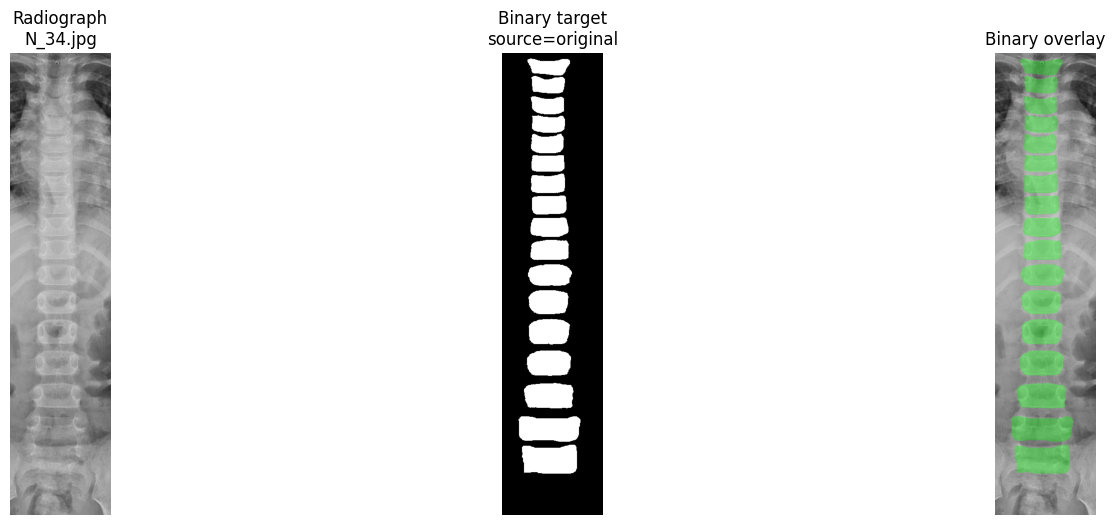

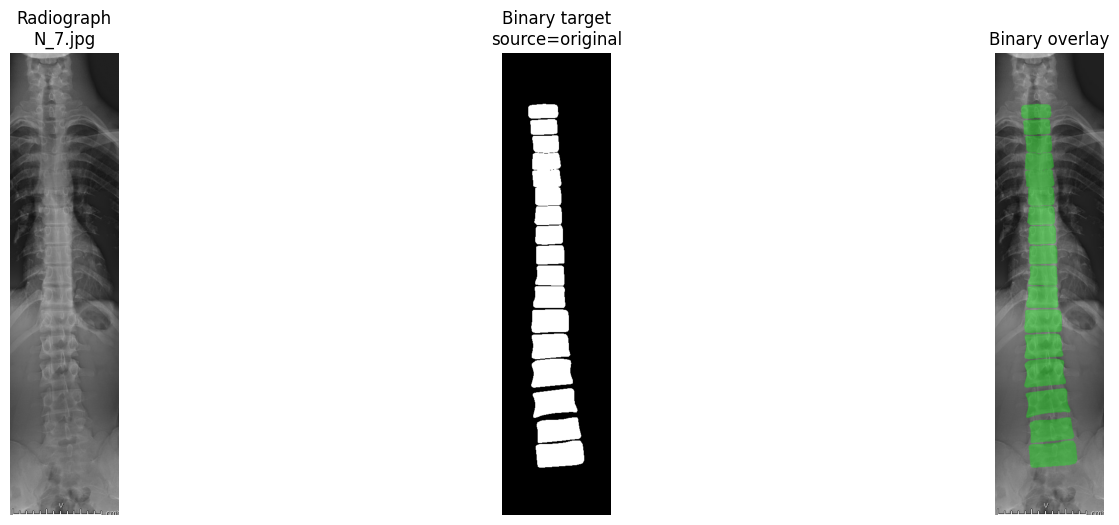

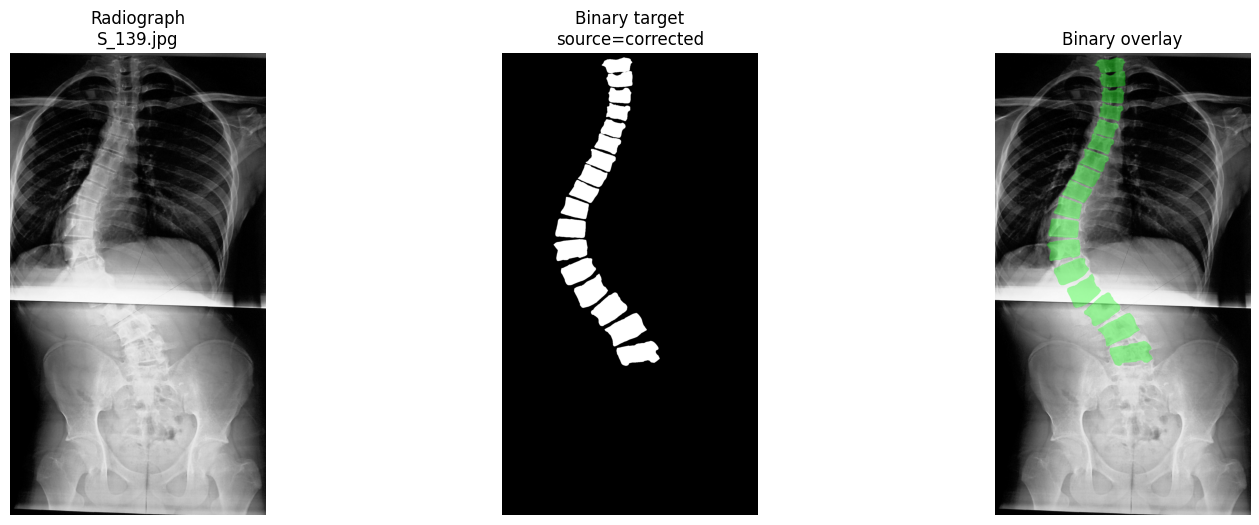

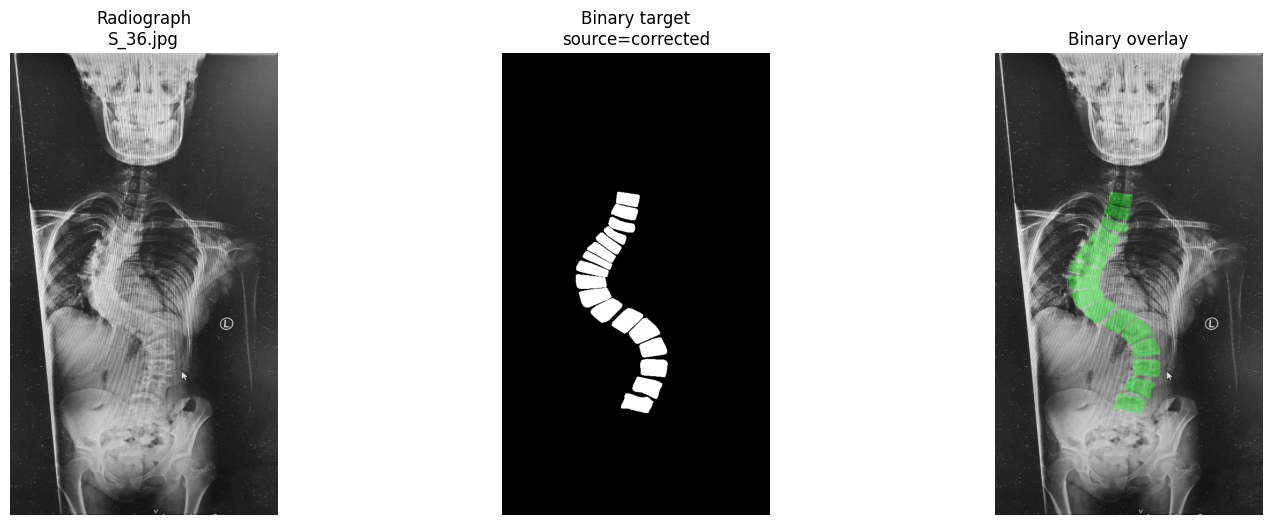

In [8]:
# =========================================================
# Visual sanity check: original image + binary target overlay
# =========================================================

def make_binary_color_mask(binary_mask):
    color = np.zeros((*binary_mask.shape, 3), dtype=np.uint8)
    color[binary_mask > 0] = [0, 255, 0]
    return color

def overlay_binary_mask(image_gray, binary_mask, alpha=0.35):
    rgb = np.stack([image_gray, image_gray, image_gray], axis=-1).astype(np.float32)
    color = make_binary_color_mask(binary_mask).astype(np.float32)

    out = rgb.copy()
    fg = binary_mask > 0
    out[fg] = (1 - alpha) * rgb[fg] + alpha * color[fg]
    return np.clip(out, 0, 255).astype(np.uint8)

sample_df = manifest_clean.sample(
    n=min(CONFIG["num_visual_checks"], len(manifest_clean)),
    random_state=CONFIG["seed"]
)

for _, row in sample_df.iterrows():
    image = load_image_grayscale(row["image_path"])
    mmask = load_mask_multiclass_id(row["multiclass_mask_path"])
    bmask = multiclass_to_binary_mask(mmask)
    overlay = overlay_binary_mask(image, bmask)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    axes[0].imshow(image, cmap="gray")
    axes[0].set_title(f"Radiograph\n{row['imagen']}")
    axes[0].axis("off")

    axes[1].imshow(bmask, cmap="gray")
    axes[1].set_title(f"Binary target\nsource={row['multiclass_mask_source']}")
    axes[1].axis("off")

    axes[2].imshow(overlay)
    axes[2].set_title("Binary overlay")
    axes[2].axis("off")

    plt.show()

In [9]:
# =========================================================
# Section 3 — Train / val / test split
# =========================================================

from sklearn.model_selection import train_test_split

SPLIT_CONFIG = {
    "test_size": 0.15,
    "val_size_within_remaining": 0.17647058823529413,  # gives about 15% val overall
    "prefer_patient_level_split": True,
    "stratify_by_group_if_possible": True,
    "seed": CONFIG["seed"],
}

def safe_train_test_split_df(df_in, test_size, stratify_col=None, random_state=42):
    if stratify_col is not None and stratify_col in df_in.columns:
        vc = df_in[stratify_col].value_counts()
        if len(vc) >= 2 and vc.min() >= 2:
            return train_test_split(
                df_in,
                test_size=test_size,
                random_state=random_state,
                stratify=df_in[stratify_col],
            )

    return train_test_split(
        df_in,
        test_size=test_size,
        random_state=random_state,
        stratify=None,
    )

patient_col_usable = (
    "id_paciente" in manifest_clean.columns
    and manifest_clean["id_paciente"].notna().all()
    and manifest_clean["id_paciente"].astype(str).str.strip().ne("").all()
)

if SPLIT_CONFIG["prefer_patient_level_split"] and patient_col_usable:
    patient_summary = (
        manifest_clean
        .groupby("id_paciente")
        .agg(
            n_images=("imagen", "count"),
            grupo_mode=("grupo", lambda x: x.mode().iloc[0] if not x.mode().empty else x.iloc[0]),
        )
        .reset_index()
    )

    split_unit_df = patient_summary.copy()
    split_id_col = "id_paciente"
    stratify_col = "grupo_mode" if SPLIT_CONFIG["stratify_by_group_if_possible"] else None
    print("Using patient-level split.")
else:
    split_unit_df = manifest_clean[["imagen", "grupo"]].copy()
    split_unit_df["id_for_split"] = split_unit_df["imagen"]
    split_id_col = "id_for_split"
    stratify_col = "grupo" if SPLIT_CONFIG["stratify_by_group_if_possible"] else None
    print("Using image-level split.")

trainval_units, test_units = safe_train_test_split_df(
    split_unit_df,
    test_size=SPLIT_CONFIG["test_size"],
    stratify_col=stratify_col,
    random_state=SPLIT_CONFIG["seed"],
)

val_stratify_col = stratify_col if stratify_col in trainval_units.columns else None

train_units, val_units = safe_train_test_split_df(
    trainval_units,
    test_size=SPLIT_CONFIG["val_size_within_remaining"],
    stratify_col=val_stratify_col,
    random_state=SPLIT_CONFIG["seed"],
)

if SPLIT_CONFIG["prefer_patient_level_split"] and patient_col_usable:
    train_ids = set(train_units["id_paciente"])
    val_ids = set(val_units["id_paciente"])
    test_ids = set(test_units["id_paciente"])

    train_manifest = manifest_clean[manifest_clean["id_paciente"].isin(train_ids)].copy()
    val_manifest = manifest_clean[manifest_clean["id_paciente"].isin(val_ids)].copy()
    test_manifest = manifest_clean[manifest_clean["id_paciente"].isin(test_ids)].copy()
else:
    train_ids = set(train_units[split_id_col])
    val_ids = set(val_units[split_id_col])
    test_ids = set(test_units[split_id_col])

    train_manifest = manifest_clean[manifest_clean["imagen"].isin(train_ids)].copy()
    val_manifest = manifest_clean[manifest_clean["imagen"].isin(val_ids)].copy()
    test_manifest = manifest_clean[manifest_clean["imagen"].isin(test_ids)].copy()

train_manifest["split"] = "train"
val_manifest["split"] = "val"
test_manifest["split"] = "test"

all_manifest = pd.concat(
    [train_manifest, val_manifest, test_manifest],
    axis=0
).reset_index(drop=True)

print("Split sizes:")
print("train:", len(train_manifest))
print("val  :", len(val_manifest))
print("test :", len(test_manifest))

display(all_manifest["split"].value_counts().rename("count").to_frame())

print("\nGroup distribution by split:")
display(pd.crosstab(all_manifest["split"], all_manifest["grupo"]))

Using patient-level split.
Split sizes:
train: 173
val  : 37
test : 38


,count
split,
train,173
test,38
val,37



Group distribution by split:


grupo,Normal,Scoliosis
split,,
test,11,27
train,49,124
val,11,26


In [10]:
# =========================================================
# Save binary split manifests
# =========================================================

BINARY_META_DIR = META_ROOT / "binary_spine_segmentation"
BINARY_META_DIR.mkdir(parents=True, exist_ok=True)

train_manifest_path = BINARY_META_DIR / "train_binary_manifest.csv"
val_manifest_path = BINARY_META_DIR / "val_binary_manifest.csv"
test_manifest_path = BINARY_META_DIR / "test_binary_manifest.csv"
all_manifest_path = BINARY_META_DIR / "all_binary_manifest_with_splits.csv"

train_manifest.to_csv(train_manifest_path, index=False)
val_manifest.to_csv(val_manifest_path, index=False)
test_manifest.to_csv(test_manifest_path, index=False)
all_manifest.to_csv(all_manifest_path, index=False)

print("Saved:")
print(train_manifest_path)
print(val_manifest_path)
print(test_manifest_path)
print(all_manifest_path)

Saved:
/content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/meta/binary_spine_segmentation/train_binary_manifest.csv
/content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/meta/binary_spine_segmentation/val_binary_manifest.csv
/content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/meta/binary_spine_segmentation/test_binary_manifest.csv
/content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/meta/binary_spine_segmentation/all_binary_manifest_with_splits.csv


In [11]:
# =========================================================
# Section 4 — Export YOLO binary segmentation dataset
# =========================================================

EXPORT_CONFIG = {
    "dataset_variant": "binary_spine_region_corrected_priority",
    "img_size": 960,

    # Set to True only if you want a tiny export for debugging.
    "debug_subset": False,
    "debug_train_max": 24,
    "debug_val_max": 8,
    "debug_test_max": 8,

    # Image preprocessing
    "apply_clahe": True,
    "clahe_clip_limit": 2.0,
    "clahe_tile_grid_size": (8, 8),

    # Polygon extraction
    "min_contour_area_px": 20,
    "polygon_epsilon_ratio": 0.0015,
    "min_polygon_points": 3,

    # Output
    "export_image_ext": ".png",
    "save_debug_overlays": True,
    "clear_existing_export": True,
}

YOLO_EXPORT_BASE_ROOT = EXPORTS_ROOT / "yolo_binary_spine_seg"
YOLO_ROOT = YOLO_EXPORT_BASE_ROOT / EXPORT_CONFIG["dataset_variant"]

YOLO_IMAGES_DIR = YOLO_ROOT / "images"
YOLO_LABELS_DIR = YOLO_ROOT / "labels"
YOLO_DEBUG_DIR = YOLO_ROOT / "debug_overlays"
YOLO_META_DIR = YOLO_ROOT / "meta"

if EXPORT_CONFIG["clear_existing_export"] and YOLO_ROOT.exists():
    shutil.rmtree(YOLO_ROOT)

for split in ["train", "val", "test"]:
    (YOLO_IMAGES_DIR / split).mkdir(parents=True, exist_ok=True)
    (YOLO_LABELS_DIR / split).mkdir(parents=True, exist_ok=True)
    (YOLO_DEBUG_DIR / split).mkdir(parents=True, exist_ok=True)

YOLO_META_DIR.mkdir(parents=True, exist_ok=True)

print("YOLO_ROOT:", YOLO_ROOT)

YOLO_ROOT: /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/exports/yolo_binary_spine_seg/binary_spine_region_corrected_priority


In [12]:
# =========================================================
# Image preprocessing and binary polygon extraction
# =========================================================

def apply_clahe_to_uint8(gray_uint8, clip_limit=2.0, tile_grid_size=(8, 8)):
    clahe = cv2.createCLAHE(
        clipLimit=clip_limit,
        tileGridSize=tile_grid_size,
    )
    return clahe.apply(gray_uint8)

def preprocess_radiograph_for_export(image_gray_uint8, cfg):
    img = image_gray_uint8.copy()

    if cfg["apply_clahe"]:
        img = apply_clahe_to_uint8(
            img,
            clip_limit=cfg["clahe_clip_limit"],
            tile_grid_size=cfg["clahe_tile_grid_size"],
        )

    return img

def resize_image_and_mask(image_gray_uint8, binary_mask_uint8, out_size):
    image_resized = cv2.resize(
        image_gray_uint8,
        (out_size, out_size),
        interpolation=cv2.INTER_LINEAR,
    )

    mask_resized = cv2.resize(
        binary_mask_uint8.astype(np.uint8),
        (out_size, out_size),
        interpolation=cv2.INTER_NEAREST,
    )

    mask_resized = (mask_resized > 0).astype(np.uint8)

    return image_resized, mask_resized

def gray_to_rgb(gray_uint8):
    return np.stack([gray_uint8, gray_uint8, gray_uint8], axis=-1)

def contour_to_normalized_polygon(contour, img_w, img_h, epsilon_ratio=0.0015):
    perimeter = cv2.arcLength(contour, True)

    if perimeter <= 0:
        return None

    epsilon = epsilon_ratio * perimeter
    approx = cv2.approxPolyDP(contour, epsilon, True)

    pts = approx.reshape(-1, 2)

    if len(pts) < 3:
        return None

    polygon = []

    for x, y in pts:
        x_norm = np.clip(x / img_w, 0.0, 1.0)
        y_norm = np.clip(y / img_h, 0.0, 1.0)
        polygon.extend([float(x_norm), float(y_norm)])

    return polygon

def extract_yolo_segments_from_binary_mask(binary_mask, cfg):
    """
    YOLO binary segmentation labels:
    class 0 = any annotated vertebra / spine region
    """
    img_h, img_w = binary_mask.shape[:2]

    binary_255 = (binary_mask > 0).astype(np.uint8) * 255

    contours, _ = cv2.findContours(
        binary_255,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE,
    )

    label_lines = []
    segment_records = []

    for contour in contours:
        area = cv2.contourArea(contour)

        if area < cfg["min_contour_area_px"]:
            continue

        polygon = contour_to_normalized_polygon(
            contour,
            img_w=img_w,
            img_h=img_h,
            epsilon_ratio=cfg["polygon_epsilon_ratio"],
        )

        if polygon is None:
            continue

        num_points = len(polygon) // 2

        if num_points < cfg["min_polygon_points"]:
            continue

        # Binary YOLO class: 0
        line = ["0"] + [f"{v:.6f}" for v in polygon]
        label_lines.append(" ".join(line))

        segment_records.append({
            "yolo_class_id": 0,
            "class_name": "vertebra_spine_region",
            "contour_area_px": float(area),
            "num_polygon_points": int(num_points),
        })

    return label_lines, segment_records

In [13]:
# =========================================================
# Export one sample and all splits
# =========================================================

def maybe_debug_subset(df_split, split_name, cfg):
    if not cfg["debug_subset"]:
        return df_split.copy().reset_index(drop=True)

    limit = {
        "train": cfg["debug_train_max"],
        "val": cfg["debug_val_max"],
        "test": cfg["debug_test_max"],
    }[split_name]

    return df_split.sample(
        n=min(limit, len(df_split)),
        random_state=CONFIG["seed"],
    ).reset_index(drop=True)

def export_one_binary_sample(row, split_name, cfg):
    image_path = Path(row["image_path"])
    mask_path = Path(row["multiclass_mask_path"])

    image_gray = load_image_grayscale(image_path)
    multiclass_mask = load_mask_multiclass_id(mask_path)
    binary_mask = multiclass_to_binary_mask(multiclass_mask)

    assert image_gray.shape[:2] == binary_mask.shape[:2], (
        f"Image/mask size mismatch: {image_path} | {mask_path}"
    )

    image_gray = preprocess_radiograph_for_export(image_gray, cfg)

    image_resized, binary_resized = resize_image_and_mask(
        image_gray,
        binary_mask,
        out_size=cfg["img_size"],
    )

    image_rgb = gray_to_rgb(image_resized)

    label_lines, segment_records = extract_yolo_segments_from_binary_mask(
        binary_resized,
        cfg,
    )

    stem = Path(str(row["imagen"])).stem
    export_image_name = f"{stem}{cfg['export_image_ext']}"
    export_label_name = f"{stem}.txt"

    out_image_path = YOLO_IMAGES_DIR / split_name / export_image_name
    out_label_path = YOLO_LABELS_DIR / split_name / export_label_name

    Image.fromarray(image_rgb).save(out_image_path)

    with open(out_label_path, "w", encoding="utf-8") as f:
        for line in label_lines:
            f.write(line + "\n")

    debug_overlay_path = None
    if cfg["save_debug_overlays"]:
        overlay = overlay_binary_mask(image_resized, binary_resized, alpha=0.35)
        debug_overlay_path = YOLO_DEBUG_DIR / split_name / export_image_name
        Image.fromarray(overlay).save(debug_overlay_path)

    export_record = {
        "split": split_name,
        "imagen": row["imagen"],
        "grupo": row["grupo"],
        "id_paciente": row["id_paciente"],
        "source_image_path": str(image_path),
        "source_multiclass_mask_path": str(mask_path),
        "mask_source": row["multiclass_mask_source"],
        "export_image_path": str(out_image_path),
        "export_label_path": str(out_label_path),
        "debug_overlay_path": str(debug_overlay_path) if debug_overlay_path else None,
        "num_segments": len(segment_records),
        "binary_fg_pixels_after_resize": int(binary_resized.sum()),
        "export_size": cfg["img_size"],
    }

    return export_record, segment_records

train_export_df = maybe_debug_subset(train_manifest, "train", EXPORT_CONFIG)
val_export_df = maybe_debug_subset(val_manifest, "val", EXPORT_CONFIG)
test_export_df = maybe_debug_subset(test_manifest, "test", EXPORT_CONFIG)

all_export_records = []
all_segment_records = []

for split_name, split_df in [
    ("train", train_export_df),
    ("val", val_export_df),
    ("test", test_export_df),
]:
    print(f"Exporting {split_name}: {len(split_df)} samples")

    for _, row in split_df.iterrows():
        export_record, segment_records = export_one_binary_sample(
            row,
            split_name,
            EXPORT_CONFIG,
        )

        all_export_records.append(export_record)

        for seg in segment_records:
            seg_row = export_record.copy()
            seg_row.update(seg)
            all_segment_records.append(seg_row)

export_manifest_df = pd.DataFrame(all_export_records)
export_segments_df = pd.DataFrame(all_segment_records)

print("\nExport complete.")
print("Images exported :", len(export_manifest_df))
print("Segments exported:", len(export_segments_df))

display(export_manifest_df.head())
display(export_segments_df.head())

Exporting train: 173 samples
Exporting val: 37 samples
Exporting test: 38 samples

Export complete.
Images exported : 248
Segments exported: 3008


,split,imagen,grupo,id_paciente,source_image_path,source_multiclass_mask_path,mask_source,export_image_path,export_label_path,debug_overlay_path,num_segments,binary_fg_pixels_after_resize,export_size
0,train,N_4.jpg,Normal,4,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,original,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,13,140523,960
1,train,N_5.jpg,Normal,5,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,original,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,6,125421,960
2,train,N_7.jpg,Normal,7,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,original,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,13,202374,960
3,train,N_8.jpg,Normal,8,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,original,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,11,95039,960
4,train,N_9.jpg,Normal,9,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,original,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,8,139524,960


,split,imagen,grupo,id_paciente,source_image_path,source_multiclass_mask_path,mask_source,export_image_path,export_label_path,debug_overlay_path,num_segments,binary_fg_pixels_after_resize,export_size,yolo_class_id,class_name,contour_area_px,num_polygon_points
0,train,N_4.jpg,Normal,4,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,original,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,13,140523,960,0,vertebra_spine_region,31432.0,53
1,train,N_4.jpg,Normal,4,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,original,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,13,140523,960,0,vertebra_spine_region,10332.5,26
2,train,N_4.jpg,Normal,4,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,original,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,13,140523,960,0,vertebra_spine_region,9959.0,35
3,train,N_4.jpg,Normal,4,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,original,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,13,140523,960,0,vertebra_spine_region,10010.5,29
4,train,N_4.jpg,Normal,4,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,original,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,13,140523,960,0,vertebra_spine_region,9290.0,30


In [14]:
# =========================================================
# Save YOLO binary dataset YAML
# =========================================================

yolo_yaml_text = f"""path: {YOLO_ROOT}
train: images/train
val: images/val
test: images/test

names:
  0: vertebra_spine_region
"""

yolo_yaml_path = YOLO_ROOT / "dataset.yaml"

with open(yolo_yaml_path, "w", encoding="utf-8") as f:
    f.write(yolo_yaml_text)

export_manifest_path = YOLO_META_DIR / "binary_export_manifest.csv"
export_segments_path = YOLO_META_DIR / "binary_export_segments.csv"

export_manifest_df.to_csv(export_manifest_path, index=False)
export_segments_df.to_csv(export_segments_path, index=False)

export_config_path = YOLO_META_DIR / "binary_export_config.json"
with open(export_config_path, "w", encoding="utf-8") as f:
    json.dump(
        {
            "export_config": EXPORT_CONFIG,
            "yolo_root": str(YOLO_ROOT),
            "dataset_yaml": str(yolo_yaml_path),
            "class_names": {0: "vertebra_spine_region"},
        },
        f,
        indent=2,
        ensure_ascii=False,
        default=str,
    )

print("Saved dataset YAML:")
print(yolo_yaml_path)
print("\n" + yolo_yaml_text)

print("Saved export manifest:", export_manifest_path)
print("Saved segment manifest:", export_segments_path)
print("Saved export config   :", export_config_path)

Saved dataset YAML:
/content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/exports/yolo_binary_spine_seg/binary_spine_region_corrected_priority/dataset.yaml

path: /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/exports/yolo_binary_spine_seg/binary_spine_region_corrected_priority
train: images/train
val: images/val
test: images/test

names:
  0: vertebra_spine_region

Saved export manifest: /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/exports/yolo_binary_spine_seg/binary_spine_region_corrected_priority/meta/binary_export_manifest.csv
Saved segment manifest: /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/exports/yolo_binary_spine_seg/binary

In [15]:
# =========================================================
# Export quality checks
# =========================================================

for split in ["train", "val", "test"]:
    image_count = len(list((YOLO_IMAGES_DIR / split).glob("*")))
    label_count = len(list((YOLO_LABELS_DIR / split).glob("*.txt")))

    print(f"{split:5s} images: {image_count:4d} | labels: {label_count:4d}")

    assert image_count == label_count, f"Image/label count mismatch in {split}"

empty_label_files = []

for label_path in YOLO_LABELS_DIR.rglob("*.txt"):
    text = label_path.read_text(encoding="utf-8").strip()
    if text == "":
        empty_label_files.append(label_path)

print("Empty label files:", len(empty_label_files))

if len(empty_label_files) > 0:
    print("First empty labels:")
    for p in empty_label_files[:10]:
        print(p)

print("\nYOLO export ready.")

train images:  173 | labels:  173
val   images:   37 | labels:   37
test  images:   38 | labels:   38
Empty label files: 0

YOLO export ready.


In [16]:
# =========================================================
# Section 5 — Train YOLOv8 binary segmentation model
# =========================================================

try:
    import ultralytics
    from ultralytics import YOLO
    print("ultralytics already installed:", ultralytics.__version__)
except Exception:
    !pip install -q ultralytics
    import ultralytics
    from ultralytics import YOLO
    print("ultralytics installed:", ultralytics.__version__)

import torch

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 76.8 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
ultralytics installed: 8.4.46
Torch version: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA A100-SXM4-40GB


In [17]:
# =========================================================
# Binary training config
# =========================================================

def detect_training_device():
    return 0 if torch.cuda.is_available() else "cpu"

DEVICE = detect_training_device()

TRAIN_CONFIG = {
    "run_name_prefix": "vertebra_yolov8m_binary_spine_premask",
    "model_name": "yolov8m-seg.pt",

    "dataset_yaml": str(yolo_yaml_path),
    "training_runs_root": str(TRAINING_RUNS_ROOT),

    "seed": CONFIG["seed"],

    # Colab settings
    "epochs": 120,
    "imgsz": EXPORT_CONFIG["img_size"],
    "batch": 8,
    "workers": 2 if torch.cuda.is_available() else 0,
    "patience": 20,

    # Optimizer
    "optimizer": "AdamW",
    "lr0": 5.0e-4,
    "lrf": 1e-2,
    "weight_decay": 5e-4,

    # Saving / validation
    "val": True,
    "save": True,
    "save_period": 10,
    "plots": True,
    "amp": True if torch.cuda.is_available() else False,
    "deterministic": True,

    # Safe medical-image augmentations
    "degrees": 4.0,
    "translate": 0.03,
    "scale": 0.08,
    "shear": 0.0,
    "perspective": 0.0,

    # Avoid anatomy-breaking transforms
    "fliplr": 0.0,
    "flipud": 0.0,

    # Avoid aggressive composition augmentations
    "mosaic": 0.0,
    "mixup": 0.0,
    "copy_paste": 0.0,

    # Mild intensity variation
    "hsv_h": 0.0,
    "hsv_s": 0.0,
    "hsv_v": 0.04,

    # Segmentation-specific
    "overlap_mask": False,
    "mask_ratio": 1,
}

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

RUN_NAME = (
    f"{TRAIN_CONFIG['run_name_prefix']}_"
    f"{EXPORT_CONFIG['dataset_variant']}_"
    f"img{TRAIN_CONFIG['imgsz']}_"
    f"seed{TRAIN_CONFIG['seed']}_"
    f"{timestamp}"
)

RUN_DIR = TRAINING_RUNS_ROOT / RUN_NAME
WEIGHTS_DIR = RUN_DIR / "weights"

BEST_WEIGHTS_PATH = WEIGHTS_DIR / "best.pt"
LAST_WEIGHTS_PATH = WEIGHTS_DIR / "last.pt"
RESULTS_CSV_PATH = RUN_DIR / "results.csv"
ARGS_YAML_PATH = RUN_DIR / "args.yaml"

print("DEVICE:", DEVICE)
print("RUN_NAME:", RUN_NAME)
print("RUN_DIR :", RUN_DIR)
print(json.dumps(TRAIN_CONFIG, indent=2, default=str))

DEVICE: 0
RUN_NAME: vertebra_yolov8m_binary_spine_premask_binary_spine_region_corrected_priority_img960_seed42_20260505_171153
RUN_DIR : /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/training_runs/vertebra_yolov8m_binary_spine_premask_binary_spine_region_corrected_priority_img960_seed42_20260505_171153
{
  "run_name_prefix": "vertebra_yolov8m_binary_spine_premask",
  "model_name": "yolov8m-seg.pt",
  "dataset_yaml": "/content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/exports/yolo_binary_spine_seg/binary_spine_region_corrected_priority/dataset.yaml",
  "training_runs_root": "/content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/training_runs",
  "seed": 42,
  "epochs": 120,
  "imgsz": 960,
  "batch": 8,
  "workers": 2,
  "patience"

In [18]:
# =========================================================
# Train YOLOv8m-seg binary model
# =========================================================

train_args = {
    "data": TRAIN_CONFIG["dataset_yaml"],
    "epochs": TRAIN_CONFIG["epochs"],
    "imgsz": TRAIN_CONFIG["imgsz"],
    "batch": TRAIN_CONFIG["batch"],
    "device": DEVICE,
    "workers": TRAIN_CONFIG["workers"],
    "project": TRAIN_CONFIG["training_runs_root"],
    "name": RUN_NAME,
    "seed": TRAIN_CONFIG["seed"],
    "deterministic": TRAIN_CONFIG["deterministic"],

    "optimizer": TRAIN_CONFIG["optimizer"],
    "lr0": TRAIN_CONFIG["lr0"],
    "lrf": TRAIN_CONFIG["lrf"],
    "weight_decay": TRAIN_CONFIG["weight_decay"],

    "val": TRAIN_CONFIG["val"],
    "save": TRAIN_CONFIG["save"],
    "save_period": TRAIN_CONFIG["save_period"],
    "patience": TRAIN_CONFIG["patience"],
    "plots": TRAIN_CONFIG["plots"],
    "amp": TRAIN_CONFIG["amp"],

    # Safe medical-image augmentations
    "degrees": TRAIN_CONFIG["degrees"],
    "translate": TRAIN_CONFIG["translate"],
    "scale": TRAIN_CONFIG["scale"],
    "shear": TRAIN_CONFIG["shear"],
    "perspective": TRAIN_CONFIG["perspective"],
    "fliplr": TRAIN_CONFIG["fliplr"],
    "flipud": TRAIN_CONFIG["flipud"],
    "mosaic": TRAIN_CONFIG["mosaic"],
    "mixup": TRAIN_CONFIG["mixup"],
    "copy_paste": TRAIN_CONFIG["copy_paste"],
    "hsv_h": TRAIN_CONFIG["hsv_h"],
    "hsv_s": TRAIN_CONFIG["hsv_s"],
    "hsv_v": TRAIN_CONFIG["hsv_v"],

    "overlap_mask": TRAIN_CONFIG["overlap_mask"],
    "mask_ratio": TRAIN_CONFIG["mask_ratio"],
}

print(json.dumps(train_args, indent=2, default=str))

model = YOLO(TRAIN_CONFIG["model_name"])
train_results = model.train(**train_args)

print("Training finished.")
print(train_results)

{
  "data": "/content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/exports/yolo_binary_spine_seg/binary_spine_region_corrected_priority/dataset.yaml",
  "epochs": 120,
  "imgsz": 960,
  "batch": 8,
  "device": 0,
  "workers": 2,
  "project": "/content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/training_runs",
  "name": "vertebra_yolov8m_binary_spine_premask_binary_spine_region_corrected_priority_img960_seed42_20260505_171153",
  "seed": 42,
  "deterministic": true,
  "optimizer": "AdamW",
  "lr0": 0.0005,
  "lrf": 0.01,
  "weight_decay": 0.0005,
  "val": true,
  "save": true,
  "save_period": 10,
  "patience": 20,
  "plots": true,
  "amp": true,
  "degrees": 4.0,
  "translate": 0.03,
  "scale": 0.08,
  "shear": 0.0,
  "perspective": 0.0,
  "fliplr": 0.0,
  "flipud": 0.0,
  "mosaic": 0.0,
  "mixup": 0.0,
  "copy_paste": 0

In [19]:
# =========================================================
# Resolve training outputs
# =========================================================

RUN_DIR = TRAINING_RUNS_ROOT / RUN_NAME
WEIGHTS_DIR = RUN_DIR / "weights"

BEST_WEIGHTS_PATH = WEIGHTS_DIR / "best.pt"
LAST_WEIGHTS_PATH = WEIGHTS_DIR / "last.pt"
RESULTS_CSV_PATH = RUN_DIR / "results.csv"
ARGS_YAML_PATH = RUN_DIR / "args.yaml"

print("RUN_DIR           :", RUN_DIR)
print("BEST_WEIGHTS_PATH :", BEST_WEIGHTS_PATH, "| exists:", BEST_WEIGHTS_PATH.exists())
print("LAST_WEIGHTS_PATH :", LAST_WEIGHTS_PATH, "| exists:", LAST_WEIGHTS_PATH.exists())
print("RESULTS_CSV_PATH  :", RESULTS_CSV_PATH, "| exists:", RESULTS_CSV_PATH.exists())
print("ARGS_YAML_PATH    :", ARGS_YAML_PATH, "| exists:", ARGS_YAML_PATH.exists())

if RESULTS_CSV_PATH.exists():
    results_df = pd.read_csv(RESULTS_CSV_PATH)
    display(results_df.head())
    display(results_df.tail())
else:
    results_df = None
    print("results.csv not found yet.")

training_summary = {
    "run_name": RUN_NAME,
    "run_dir": str(RUN_DIR),
    "dataset_yaml": str(yolo_yaml_path),
    "best_weights_path": str(BEST_WEIGHTS_PATH),
    "last_weights_path": str(LAST_WEIGHTS_PATH),
    "results_csv_path": str(RESULTS_CSV_PATH),
    "args_yaml_path": str(ARGS_YAML_PATH),
    "binary_class": {
        "0": "vertebra_spine_region"
    },
    "source_masks": {
        "corrected_priority": CONFIG["prefer_corrected_masks"],
        "corrected_dir": str(CORRECTED_MULTICLASS_DIR),
        "fallback": "original LabelMultiClass_ID_PNG mask",
    },
    "purpose": "binary pre-mask generator for manual GIMP refinement",
    "train_config": TRAIN_CONFIG,
    "export_config": EXPORT_CONFIG,
}

training_summary_path = RUN_DIR / "binary_training_summary.json"

with open(training_summary_path, "w", encoding="utf-8") as f:
    json.dump(training_summary, f, indent=2, ensure_ascii=False, default=str)

print("Saved training summary:", training_summary_path)

RUN_DIR           : /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/training_runs/vertebra_yolov8m_binary_spine_premask_binary_spine_region_corrected_priority_img960_seed42_20260505_171153
BEST_WEIGHTS_PATH : /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/training_runs/vertebra_yolov8m_binary_spine_premask_binary_spine_region_corrected_priority_img960_seed42_20260505_171153/weights/best.pt | exists: True
LAST_WEIGHTS_PATH : /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/training_runs/vertebra_yolov8m_binary_spine_premask_binary_spine_region_corrected_priority_img960_seed42_20260505_171153/weights/last.pt | exists: True
RESULTS_CSV_PATH  : /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Desplie

,epoch,time,train/box_loss,train/seg_loss,train/cls_loss,train/dfl_loss,train/sem_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),metrics/precision(M),metrics/recall(M),metrics/mAP50(M),metrics/mAP50-95(M),val/box_loss,val/seg_loss,val/cls_loss,val/dfl_loss,val/sem_loss,lr/pg0,lr/pg1,lr/pg2
0,1,22.0394,3.18843,5.22789,3.18726,2.91632,0,0.12387,0.09492,0.03168,0.01096,0.00009,0.00235,0.00000,0.00000,3.16894,24.62660,4.86815,3.85331,0,0.000105,0.000105,0.079105
1,2,39.5391,1.44701,2.91802,1.57739,1.52790,0,0.57447,0.38498,0.38746,0.20061,0.01055,0.02113,0.00094,0.00015,1.89110,19.63460,2.13870,1.88181,0,0.000213,0.000213,0.057213
2,3,60.7531,1.27655,2.45821,1.20249,1.39574,0,0.55911,0.55072,0.49853,0.30102,0.14505,0.16901,0.05486,0.01205,1.49142,10.35680,2.04717,1.56502,0,0.000320,0.000320,0.035320
3,4,80.6649,1.18859,2.22004,1.13287,1.34640,0,0.55145,0.58920,0.48965,0.31004,0.47452,0.53991,0.39512,0.17748,1.28316,4.22488,1.74831,1.43281,0,0.000424,0.000424,0.013424
4,5,99.5104,1.13041,2.08496,1.05376,1.29757,0,0.62141,0.60877,0.59983,0.37006,0.58837,0.55164,0.51577,0.25706,1.34462,3.53447,1.48883,1.44799,0,0.000483,0.000483,0.000483


,epoch,time,train/box_loss,train/seg_loss,train/cls_loss,train/dfl_loss,train/sem_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),metrics/precision(M),metrics/recall(M),metrics/mAP50(M),metrics/mAP50-95(M),val/box_loss,val/seg_loss,val/cls_loss,val/dfl_loss,val/sem_loss,lr/pg0,lr/pg1,lr/pg2
26,27,559.612,0.59949,1.14685,0.43292,0.94231,0,0.62338,0.68383,0.62104,0.41595,0.63545,0.69014,0.63030,0.39779,1.31077,2.22839,1.32416,1.56542,0,0.000393,0.000393,0.000393
27,28,575.507,0.58227,1.14866,0.41022,0.93521,0,0.60594,0.69014,0.61856,0.39665,0.60451,0.69014,0.62012,0.39316,1.29181,2.30137,1.21743,1.53431,0,0.000389,0.000389,0.000389
28,29,591.556,0.57345,1.11796,0.40311,0.94176,0,0.65005,0.62676,0.59741,0.40428,0.65047,0.63146,0.59900,0.39432,1.33343,2.27189,1.41403,1.59405,0,0.000385,0.000385,0.000385
29,30,615.479,0.55580,1.14303,0.38476,0.92734,0,0.63076,0.66197,0.64189,0.42569,0.66683,0.61033,0.62861,0.41340,1.32918,2.23721,1.32285,1.56158,0,0.000380,0.000380,0.000380
30,31,639.960,0.55938,1.13863,0.36154,0.92478,0,0.64034,0.64789,0.62126,0.41577,0.63980,0.65493,0.61785,0.39493,1.29130,2.15165,1.26941,1.54237,0,0.000376,0.000376,0.000376


Saved training summary: /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/training_runs/vertebra_yolov8m_binary_spine_premask_binary_spine_region_corrected_priority_img960_seed42_20260505_171153/binary_training_summary.json


Available columns:
['epoch', 'time', 'train/box_loss', 'train/seg_loss', 'train/cls_loss', 'train/dfl_loss', 'train/sem_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'metrics/precision(M)', 'metrics/recall(M)', 'metrics/mAP50(M)', 'metrics/mAP50-95(M)', 'val/box_loss', 'val/seg_loss', 'val/cls_loss', 'val/dfl_loss', 'val/sem_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']


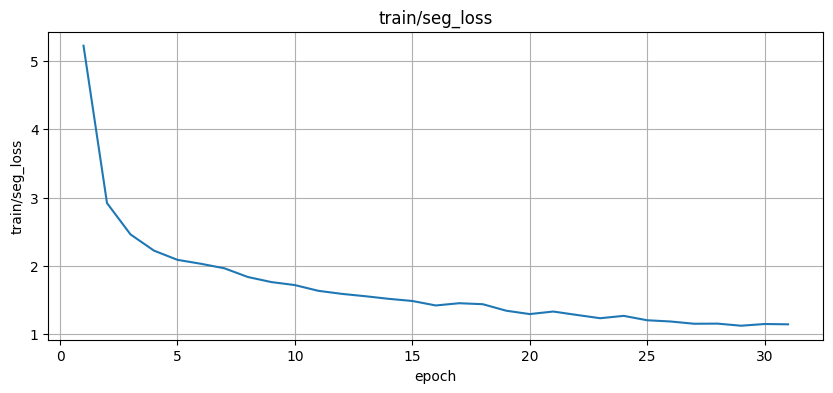

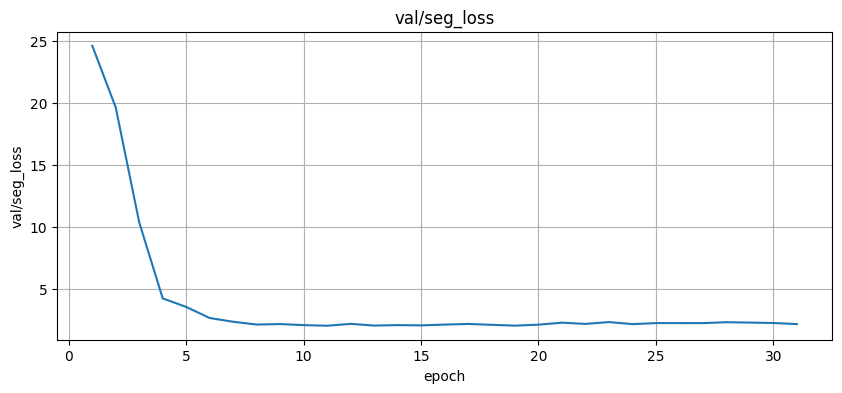

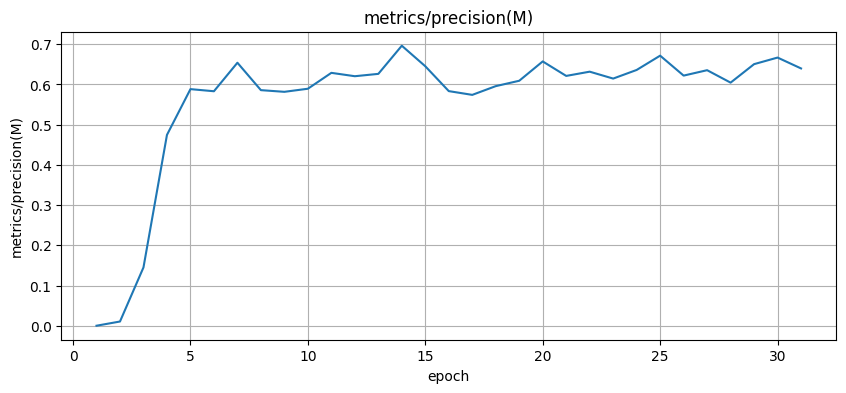

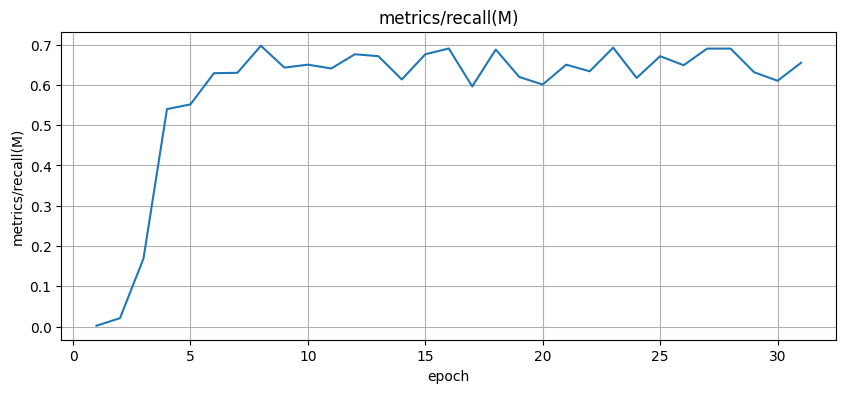

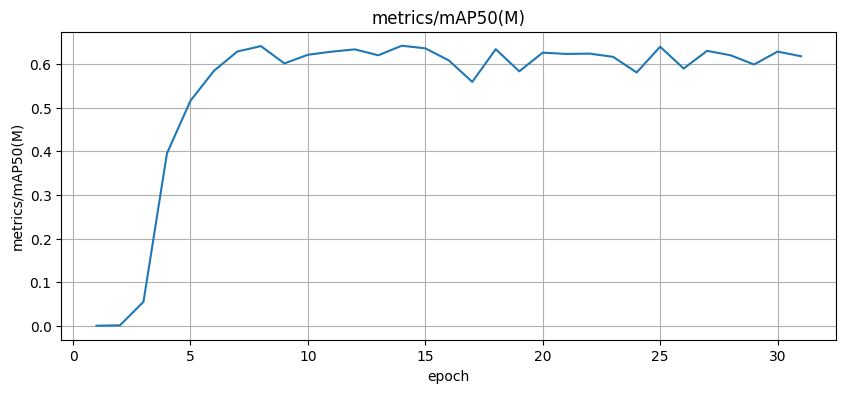

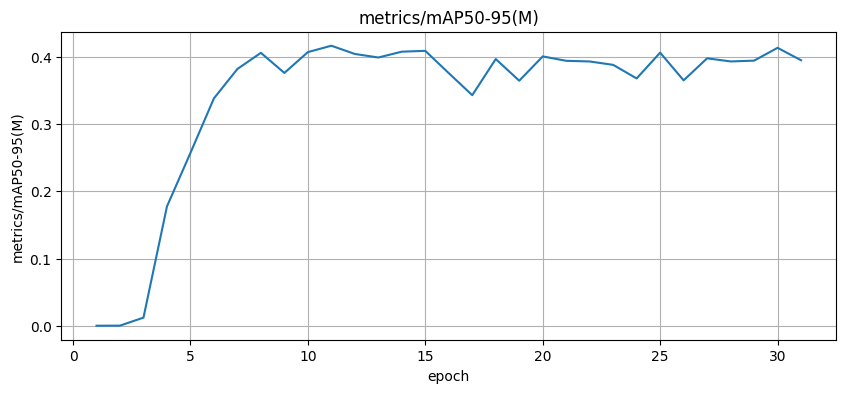

In [20]:
# =========================================================
# Plot key training curves
# =========================================================

if results_df is not None:
    print("Available columns:")
    print(list(results_df.columns))

    metric_candidates = [
        "train/seg_loss",
        "val/seg_loss",
        "metrics/precision(M)",
        "metrics/recall(M)",
        "metrics/mAP50(M)",
        "metrics/mAP50-95(M)",
    ]

    for col in metric_candidates:
        if col in results_df.columns:
            plt.figure(figsize=(10, 4))
            plt.plot(results_df["epoch"], results_df[col])
            plt.title(col)
            plt.xlabel("epoch")
            plt.ylabel(col)
            plt.grid(True)
            plt.show()
else:
    print("No results_df available.")

In [21]:
# =========================================================
# Section 6 — Evaluate binary Dice and IoU
# =========================================================

EVAL_CONFIG = {
    "split": "test",
    "conf_threshold": 0.10,
    "iou_threshold": 0.50,
    "imgsz": TRAIN_CONFIG["imgsz"],
    "max_det": 20,
    "retina_masks": True,
    "save_outputs": True,
}

EVAL_OUTPUT_DIR = RUN_DIR / "binary_evaluation"
EVAL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def dice_iou_binary(gt, pred):
    gt = gt.astype(bool)
    pred = pred.astype(bool)

    inter = np.logical_and(gt, pred).sum()
    gt_sum = gt.sum()
    pred_sum = pred.sum()
    union = np.logical_or(gt, pred).sum()

    dice = (2 * inter) / (gt_sum + pred_sum) if (gt_sum + pred_sum) > 0 else np.nan
    iou = inter / union if union > 0 else np.nan

    return float(dice), float(iou)

def build_binary_prediction_mask_from_yolo_result(result_obj, out_h, out_w, threshold=0.5):
    pred = np.zeros((out_h, out_w), dtype=np.uint8)

    if result_obj.masks is None or result_obj.boxes is None or len(result_obj.boxes) == 0:
        return pred

    masks = result_obj.masks.data.cpu().numpy()

    for mask_i in masks:
        mask_resized = cv2.resize(
            mask_i.astype(np.float32),
            (out_w, out_h),
            interpolation=cv2.INTER_NEAREST,
        )

        pred[mask_resized > threshold] = 1

    return pred

def get_eval_manifest(split_name):
    if split_name == "train":
        return train_manifest
    if split_name == "val":
        return val_manifest
    if split_name == "test":
        return test_manifest
    raise ValueError(f"Unknown split: {split_name}")

In [22]:
# =========================================================
# Run binary Dice/IoU evaluation
# =========================================================

assert BEST_WEIGHTS_PATH.exists(), f"best.pt not found: {BEST_WEIGHTS_PATH}"

eval_model = YOLO(str(BEST_WEIGHTS_PATH))
eval_manifest = get_eval_manifest(EVAL_CONFIG["split"]).reset_index(drop=True)

eval_rows = []

for idx, row in eval_manifest.iterrows():
    image_path = Path(row["image_path"])
    mask_path = Path(row["multiclass_mask_path"])

    gt_multiclass = load_mask_multiclass_id(mask_path)
    gt_binary = multiclass_to_binary_mask(gt_multiclass)

    h, w = gt_binary.shape[:2]

    results = eval_model.predict(
        source=str(image_path),
        imgsz=EVAL_CONFIG["imgsz"],
        conf=EVAL_CONFIG["conf_threshold"],
        iou=EVAL_CONFIG["iou_threshold"],
        max_det=EVAL_CONFIG["max_det"],
        retina_masks=EVAL_CONFIG["retina_masks"],
        save=False,
        verbose=False,
    )

    result = results[0]

    pred_binary = build_binary_prediction_mask_from_yolo_result(
        result,
        out_h=h,
        out_w=w,
        threshold=0.5,
    )

    dice, iou = dice_iou_binary(gt_binary, pred_binary)

    eval_rows.append({
        "split": EVAL_CONFIG["split"],
        "imagen": row["imagen"],
        "grupo": row["grupo"],
        "id_paciente": row["id_paciente"],
        "mask_source": row["multiclass_mask_source"],
        "dice": dice,
        "iou": iou,
        "gt_fg_pixels": int(gt_binary.sum()),
        "pred_fg_pixels": int(pred_binary.sum()),
        "num_boxes": 0 if result.boxes is None else len(result.boxes),
        "num_masks": 0 if result.masks is None else len(result.masks),
    })

eval_df = pd.DataFrame(eval_rows)

display(eval_df.head())
display(eval_df[["dice", "iou", "gt_fg_pixels", "pred_fg_pixels", "num_masks"]].describe())

eval_csv_path = EVAL_OUTPUT_DIR / f"binary_eval_{EVAL_CONFIG['split']}.csv"
eval_df.to_csv(eval_csv_path, index=False)

print("Saved evaluation CSV:", eval_csv_path)
print("Mean Dice:", eval_df["dice"].mean())
print("Mean IoU :", eval_df["iou"].mean())

,split,imagen,grupo,id_paciente,mask_source,dice,iou,gt_fg_pixels,pred_fg_pixels,num_boxes,num_masks
0,test,N_2.jpg,Normal,2,original,0.279428,0.162404,30464,5030,2,2
1,test,N_3.jpg,Normal,3,original,0.443710,0.285107,44866,14123,5,5
2,test,N_15.jpg,Normal,15,original,0.000000,0.000000,27118,0,0,0
3,test,N_21.jpg,Normal,21,original,0.000000,0.000000,17313,3849,2,2
4,test,N_22.jpg,Normal,22,original,0.138418,0.074355,39373,3078,1,1


,dice,iou,gt_fg_pixels,pred_fg_pixels,num_masks
count,38.000000,38.000000,3.800000e+01,38.000000,38.000000
mean,0.403104,0.290787,1.477338e+05,95595.500000,6.657895
std,0.279844,0.227006,2.683798e+05,179939.115598,5.946956
min,0.000000,0.000000,1.461900e+04,0.000000,0.000000
25%,0.154110,0.083493,2.305650e+04,3270.750000,1.000000
50%,0.441250,0.283082,3.090550e+04,18289.000000,6.500000
75%,0.646561,0.477824,1.750010e+05,55930.500000,9.000000
max,0.807648,0.677357,1.282415e+06,888117.000000,20.000000


Saved evaluation CSV: /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/training_runs/vertebra_yolov8m_binary_spine_premask_binary_spine_region_corrected_priority_img960_seed42_20260505_171153/binary_evaluation/binary_eval_test.csv
Mean Dice: 0.40310423715670557
Mean IoU : 0.29078728468892345


In [23]:
# =========================================================
# Save visual evaluation overlays
# =========================================================

VIS_EVAL_CONFIG = {
    "max_visuals": 12,
    "alpha": 0.35,
}

visual_df = eval_manifest.sample(
    n=min(VIS_EVAL_CONFIG["max_visuals"], len(eval_manifest)),
    random_state=CONFIG["seed"],
).reset_index(drop=True)

VIS_EVAL_DIR = EVAL_OUTPUT_DIR / "visual_overlays"
VIS_EVAL_DIR.mkdir(parents=True, exist_ok=True)

for _, row in visual_df.iterrows():
    image_path = Path(row["image_path"])
    mask_path = Path(row["multiclass_mask_path"])

    image_gray = load_image_grayscale(image_path)
    gt_binary = multiclass_to_binary_mask(load_mask_multiclass_id(mask_path))

    h, w = gt_binary.shape[:2]

    result = eval_model.predict(
        source=str(image_path),
        imgsz=EVAL_CONFIG["imgsz"],
        conf=EVAL_CONFIG["conf_threshold"],
        iou=EVAL_CONFIG["iou_threshold"],
        max_det=EVAL_CONFIG["max_det"],
        retina_masks=EVAL_CONFIG["retina_masks"],
        save=False,
        verbose=False,
    )[0]

    pred_binary = build_binary_prediction_mask_from_yolo_result(
        result,
        out_h=h,
        out_w=w,
        threshold=0.5,
    )

    gt_overlay = overlay_binary_mask(image_gray, gt_binary, alpha=VIS_EVAL_CONFIG["alpha"])
    pred_overlay = overlay_binary_mask(image_gray, pred_binary, alpha=VIS_EVAL_CONFIG["alpha"])

    stem = Path(str(row["imagen"])).stem

    Image.fromarray(gt_overlay).save(VIS_EVAL_DIR / f"{stem}_gt_binary_overlay.png")
    Image.fromarray(pred_overlay).save(VIS_EVAL_DIR / f"{stem}_pred_binary_overlay.png")
    Image.fromarray((pred_binary * 255).astype(np.uint8)).save(VIS_EVAL_DIR / f"{stem}_pred_binary_0_255.png")

print("Saved visual evaluation overlays to:")
print(VIS_EVAL_DIR)

Saved visual evaluation overlays to:
/content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/training_runs/vertebra_yolov8m_binary_spine_premask_binary_spine_region_corrected_priority_img960_seed42_20260505_171153/binary_evaluation/visual_overlays


In [ ]:
# =========================================================
# Section 7 — Inference on 10 new JPEG images
# =========================================================

INFERENCE_CONFIG = {
    # Change this path to the Drive folder where you place the 10 new JPEGs.
    "new_images_dir": Path(
        # Update this folder path before running inference on new JPEG images.
        "/content/drive/MyDrive/REPLACE_WITH_NEW_IMAGES_DIR"
    ),

    "output_subdir_name": "new_jpeg_binary_premasks",

    "model_path": BEST_WEIGHTS_PATH,

    "imgsz": TRAIN_CONFIG["imgsz"],
    "conf_threshold": 0.10,
    "iou_threshold": 0.50,
    "max_det": 20,
    "retina_masks": True,

    # Output masks
    "mask_threshold": 0.5,
    "overlay_alpha": 0.35,

    # Bright color for GIMP preview/editing
    "bright_mask_color_rgb": [0, 255, 0],
}

NEW_IMAGES_DIR = Path(INFERENCE_CONFIG["new_images_dir"])

INFERENCE_OUTPUT_DIR = RUN_DIR / "inference" / INFERENCE_CONFIG["output_subdir_name"]
PRED_ID_MASK_DIR = INFERENCE_OUTPUT_DIR / "pred_binary_id_masks_0_1"
PRED_COLOR_MASK_DIR = INFERENCE_OUTPUT_DIR / "pred_bright_color_masks"
OVERLAY_DIR = INFERENCE_OUTPUT_DIR / "overlays"
ORIGINAL_COPY_DIR = INFERENCE_OUTPUT_DIR / "original_copies"

for p in [
    INFERENCE_OUTPUT_DIR,
    PRED_ID_MASK_DIR,
    PRED_COLOR_MASK_DIR,
    OVERLAY_DIR,
    ORIGINAL_COPY_DIR,
]:
    p.mkdir(parents=True, exist_ok=True)

print("NEW_IMAGES_DIR:", NEW_IMAGES_DIR, "| exists:", NEW_IMAGES_DIR.exists())
print("INFERENCE_OUTPUT_DIR:", INFERENCE_OUTPUT_DIR)

assert NEW_IMAGES_DIR.exists(), (
    "Please create this folder in Drive and place your 10 JPEG images there, "
    f"or update INFERENCE_CONFIG['new_images_dir']:\n{NEW_IMAGES_DIR}"
)

NEW_IMAGES_DIR: /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/new_jpeg_images_for_binary_premask | exists: True
INFERENCE_OUTPUT_DIR: /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/training_runs/vertebra_yolov8m_binary_spine_premask_binary_spine_region_corrected_priority_img960_seed42_20260505_171153/inference/new_jpeg_binary_premasks


In [26]:
# =========================================================
# Inference helpers for new JPEGs
# =========================================================

def list_new_images(folder):
    exts = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}
    return sorted([p for p in Path(folder).iterdir() if p.is_file() and p.suffix.lower() in exts])

def make_bright_color_mask(binary_mask, color_rgb):
    color_mask = np.zeros((*binary_mask.shape, 3), dtype=np.uint8)
    color_mask[binary_mask > 0] = np.array(color_rgb, dtype=np.uint8)
    return color_mask

def overlay_color_mask_on_rgb(image_rgb, binary_mask, color_rgb, alpha=0.35):
    out = image_rgb.astype(np.float32).copy()
    color = np.zeros_like(out)
    color[binary_mask > 0] = np.array(color_rgb, dtype=np.float32)

    fg = binary_mask > 0
    out[fg] = (1 - alpha) * out[fg] + alpha * color[fg]

    return np.clip(out, 0, 255).astype(np.uint8)

def build_binary_prediction_for_image(model, image_path, cfg):
    image_rgb = load_image_rgb(image_path)
    h, w = image_rgb.shape[:2]

    result = model.predict(
        source=str(image_path),
        imgsz=cfg["imgsz"],
        conf=cfg["conf_threshold"],
        iou=cfg["iou_threshold"],
        max_det=cfg["max_det"],
        retina_masks=cfg["retina_masks"],
        save=False,
        verbose=False,
    )[0]

    pred_binary = build_binary_prediction_mask_from_yolo_result(
        result,
        out_h=h,
        out_w=w,
        threshold=cfg["mask_threshold"],
    )

    return image_rgb, pred_binary, result

In [27]:
# =========================================================
# Run inference and save GIMP-friendly outputs
# =========================================================

new_image_paths = list_new_images(NEW_IMAGES_DIR)

print("Found new images:", len(new_image_paths))
for p in new_image_paths:
    print(p.name)

assert len(new_image_paths) > 0, f"No images found in: {NEW_IMAGES_DIR}"

inference_model = YOLO(str(INFERENCE_CONFIG["model_path"]))

inference_rows = []

for image_path in new_image_paths:
    image_rgb, pred_binary, result = build_binary_prediction_for_image(
        inference_model,
        image_path,
        INFERENCE_CONFIG,
    )

    stem = image_path.stem

    # 1) Original copy
    original_copy_path = ORIGINAL_COPY_DIR / image_path.name
    shutil.copy2(image_path, original_copy_path)

    # 2) Predicted binary ID mask PNG, values 0 and 1
    pred_id_mask_path = PRED_ID_MASK_DIR / f"{stem}_pred_binary_id_0_1.png"
    Image.fromarray(pred_binary.astype(np.uint8)).save(pred_id_mask_path)

    # 3) Bright binary color mask PNG
    bright_color_mask = make_bright_color_mask(
        pred_binary,
        INFERENCE_CONFIG["bright_mask_color_rgb"],
    )
    pred_color_mask_path = PRED_COLOR_MASK_DIR / f"{stem}_pred_binary_bright_color.png"
    Image.fromarray(bright_color_mask).save(pred_color_mask_path)

    # 4) Overlay image
    overlay = overlay_color_mask_on_rgb(
        image_rgb,
        pred_binary,
        INFERENCE_CONFIG["bright_mask_color_rgb"],
        alpha=INFERENCE_CONFIG["overlay_alpha"],
    )
    overlay_path = OVERLAY_DIR / f"{stem}_pred_binary_overlay.png"
    Image.fromarray(overlay).save(overlay_path)

    num_boxes = 0 if result.boxes is None else len(result.boxes)
    num_masks = 0 if result.masks is None else len(result.masks)

    inference_rows.append({
        "source_image_path": str(image_path),
        "original_copy_path": str(original_copy_path),
        "pred_binary_id_mask_0_1_path": str(pred_id_mask_path),
        "pred_bright_color_mask_path": str(pred_color_mask_path),
        "overlay_path": str(overlay_path),
        "image_h": int(image_rgb.shape[0]),
        "image_w": int(image_rgb.shape[1]),
        "pred_fg_pixels": int(pred_binary.sum()),
        "num_boxes": int(num_boxes),
        "num_masks": int(num_masks),
        "conf_threshold": INFERENCE_CONFIG["conf_threshold"],
        "iou_threshold": INFERENCE_CONFIG["iou_threshold"],
        "imgsz": INFERENCE_CONFIG["imgsz"],
    })

inference_df = pd.DataFrame(inference_rows)

inference_csv_path = INFERENCE_OUTPUT_DIR / "new_jpeg_binary_inference_summary.csv"
inference_df.to_csv(inference_csv_path, index=False)

display(inference_df)

print("Saved inference summary:", inference_csv_path)
print("Saved ID masks to       :", PRED_ID_MASK_DIR)
print("Saved color masks to    :", PRED_COLOR_MASK_DIR)
print("Saved overlays to       :", OVERLAY_DIR)

Found new images: 10
1.jpeg
10.jpeg
2.jpeg
3.jpeg
4.jpeg
5.jpeg
6.jpeg
7.jpeg
8.jpeg
9.jpeg


,source_image_path,original_copy_path,pred_binary_id_mask_0_1_path,pred_bright_color_mask_path,overlay_path,image_h,image_w,pred_fg_pixels,num_boxes,num_masks,conf_threshold,iou_threshold,imgsz
0,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,985,526,38019,9,9,0.1,0.5,960
1,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,1600,732,11230,2,2,0.1,0.5,960
2,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,1600,528,0,0,0,0.1,0.5,960
3,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,1600,435,5397,1,1,0.1,0.5,960
4,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,1600,435,50551,9,9,0.1,0.5,960
5,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,1600,453,48765,4,4,0.1,0.5,960
6,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,1600,471,9018,1,1,0.1,0.5,960
7,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,1600,628,25004,3,3,0.1,0.5,960
8,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,1600,612,27486,5,5,0.1,0.5,960
9,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,1600,589,19749,3,3,0.1,0.5,960


Saved inference summary: /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/training_runs/vertebra_yolov8m_binary_spine_premask_binary_spine_region_corrected_priority_img960_seed42_20260505_171153/inference/new_jpeg_binary_premasks/new_jpeg_binary_inference_summary.csv
Saved ID masks to       : /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/training_runs/vertebra_yolov8m_binary_spine_premask_binary_spine_region_corrected_priority_img960_seed42_20260505_171153/inference/new_jpeg_binary_premasks/pred_binary_id_masks_0_1
Saved color masks to    : /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/training_runs/vertebra_yolov8m_binary_spine_premask_binary_spine_region_corrected_priority_img960_seed42_20260505_171153/inference/new_jp

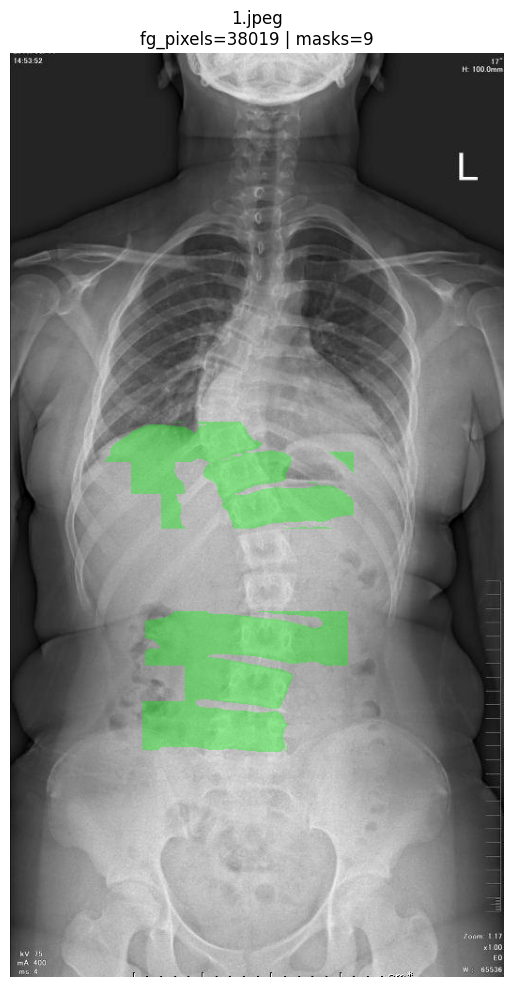

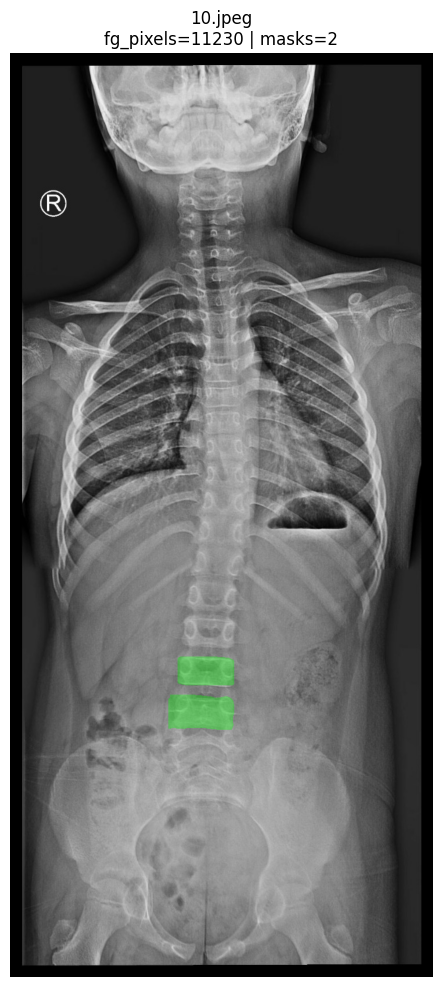

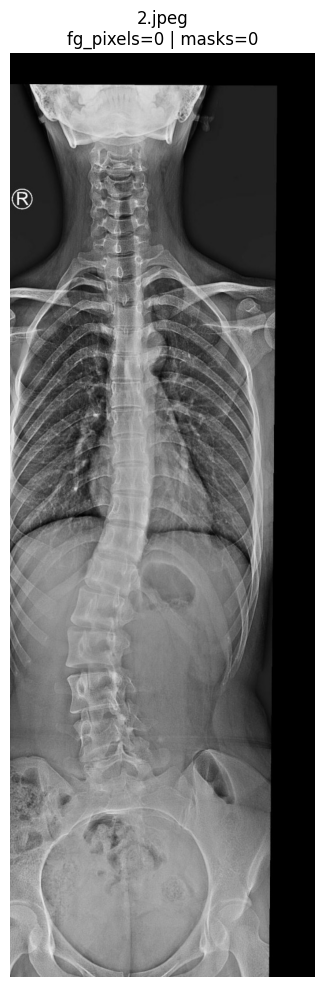

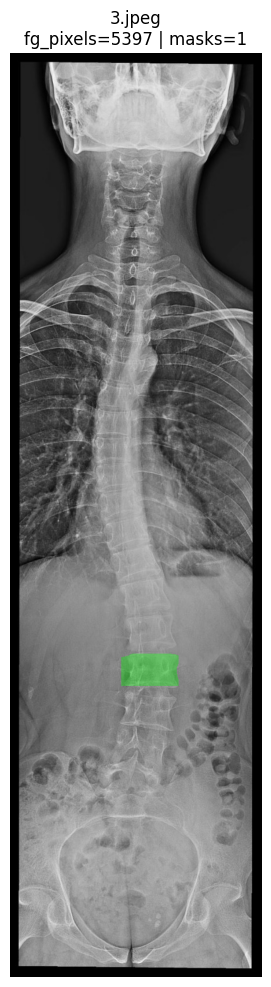

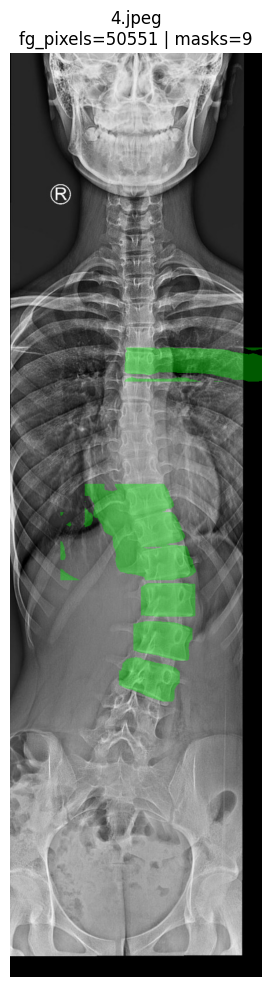

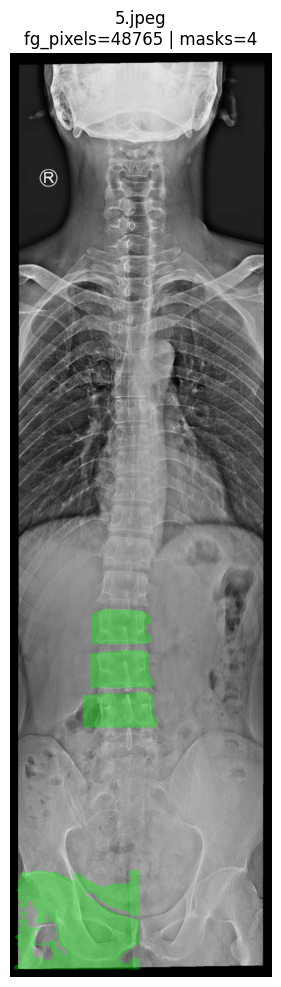

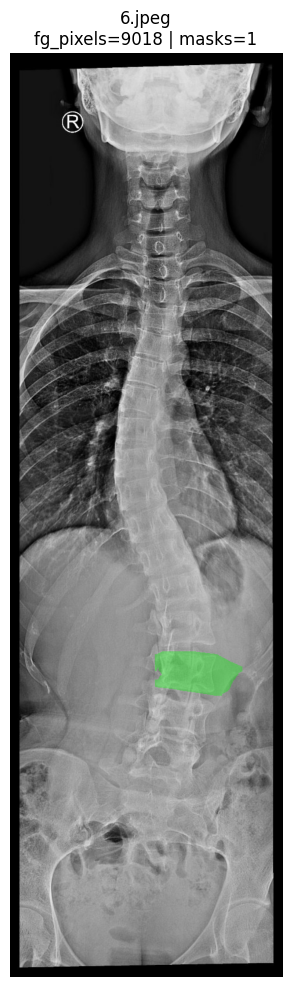

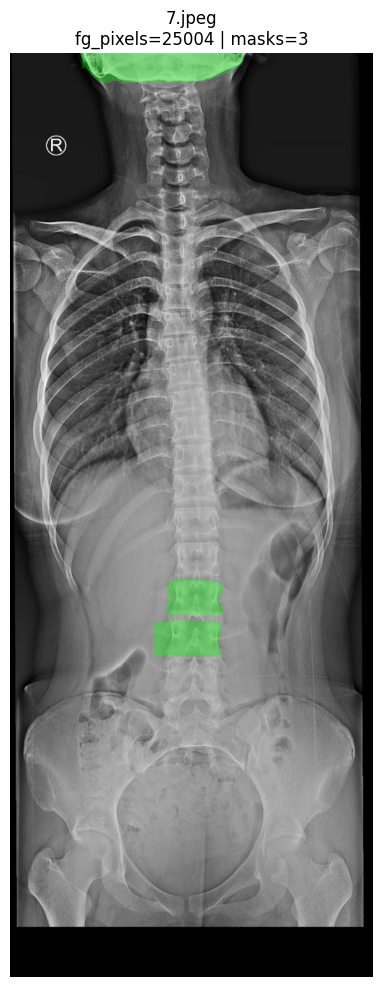

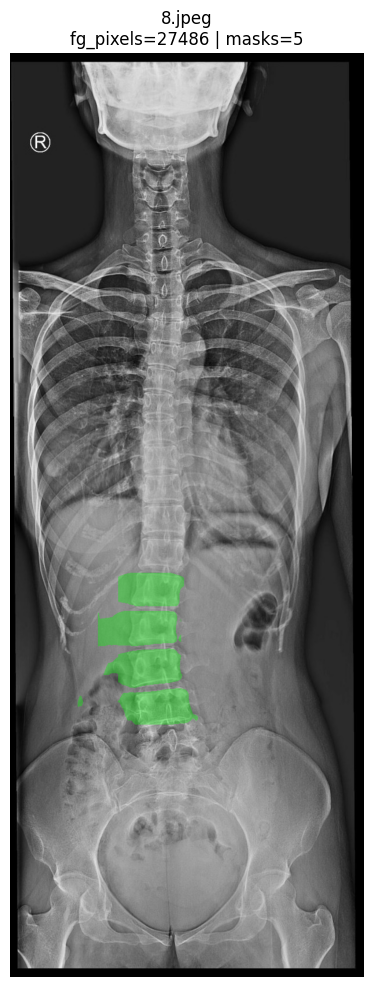

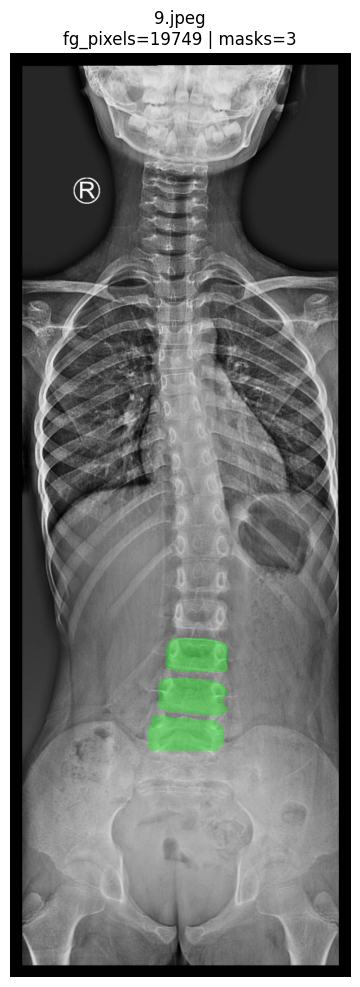

In [28]:
# =========================================================
# Display overlays for quick visual judgment
# =========================================================

for _, row in inference_df.iterrows():
    overlay = Image.open(row["overlay_path"]).convert("RGB")

    plt.figure(figsize=(8, 12))
    plt.imshow(overlay)
    plt.title(
        f"{Path(row['source_image_path']).name}\n"
        f"fg_pixels={row['pred_fg_pixels']} | masks={row['num_masks']}"
    )
    plt.axis("off")
    plt.show()

In [29]:
# =========================================================
# Optional threshold diagnostic on new JPEG images
# =========================================================

THRESHOLD_DIAG_CONFIG = {
    "enabled": False,
    "thresholds": [0.03, 0.05, 0.10, 0.15, 0.20, 0.30],
    "max_images": 10,
}

if THRESHOLD_DIAG_CONFIG["enabled"]:
    THRESHOLD_DIAG_DIR = INFERENCE_OUTPUT_DIR / "threshold_diagnostics"
    THRESHOLD_DIAG_DIR.mkdir(parents=True, exist_ok=True)

    diag_rows = []

    for image_path in new_image_paths[:THRESHOLD_DIAG_CONFIG["max_images"]]:
        image_rgb = load_image_rgb(image_path)
        h, w = image_rgb.shape[:2]

        for conf_thr in THRESHOLD_DIAG_CONFIG["thresholds"]:
            result = inference_model.predict(
                source=str(image_path),
                imgsz=INFERENCE_CONFIG["imgsz"],
                conf=conf_thr,
                iou=INFERENCE_CONFIG["iou_threshold"],
                max_det=INFERENCE_CONFIG["max_det"],
                retina_masks=INFERENCE_CONFIG["retina_masks"],
                save=False,
                verbose=False,
            )[0]

            pred_binary = build_binary_prediction_mask_from_yolo_result(
                result,
                out_h=h,
                out_w=w,
                threshold=INFERENCE_CONFIG["mask_threshold"],
            )

            overlay = overlay_color_mask_on_rgb(
                image_rgb,
                pred_binary,
                INFERENCE_CONFIG["bright_mask_color_rgb"],
                alpha=INFERENCE_CONFIG["overlay_alpha"],
            )

            stem = image_path.stem
            conf_stub = str(conf_thr).replace(".", "p")

            overlay_path = THRESHOLD_DIAG_DIR / f"{stem}_conf{conf_stub}_overlay.png"
            Image.fromarray(overlay).save(overlay_path)

            diag_rows.append({
                "image": image_path.name,
                "conf_threshold": conf_thr,
                "pred_fg_pixels": int(pred_binary.sum()),
                "num_boxes": 0 if result.boxes is None else len(result.boxes),
                "num_masks": 0 if result.masks is None else len(result.masks),
                "overlay_path": str(overlay_path),
            })

    threshold_diag_df = pd.DataFrame(diag_rows)
    threshold_diag_csv = THRESHOLD_DIAG_DIR / "threshold_diagnostic_summary.csv"
    threshold_diag_df.to_csv(threshold_diag_csv, index=False)

    display(threshold_diag_df)
    print("Saved threshold diagnostics:", THRESHOLD_DIAG_DIR)

In [30]:
# =========================================================
# Section 8 — Final artifact summary
# =========================================================

final_summary = {
    "run_name": RUN_NAME,
    "run_dir": str(RUN_DIR),
    "best_pt": str(BEST_WEIGHTS_PATH),
    "last_pt": str(LAST_WEIGHTS_PATH),
    "results_csv": str(RESULTS_CSV_PATH),
    "args_yaml": str(ARGS_YAML_PATH),
    "dataset_yaml": str(yolo_yaml_path),
    "yolo_export_root": str(YOLO_ROOT),
    "evaluation_csv": str(eval_csv_path) if "eval_csv_path" in globals() else None,
    "inference_output_dir": str(INFERENCE_OUTPUT_DIR) if "INFERENCE_OUTPUT_DIR" in globals() else None,
    "new_jpeg_inference_summary": str(inference_csv_path) if "inference_csv_path" in globals() else None,
    "pred_binary_id_masks_0_1_dir": str(PRED_ID_MASK_DIR) if "PRED_ID_MASK_DIR" in globals() else None,
    "pred_bright_color_masks_dir": str(PRED_COLOR_MASK_DIR) if "PRED_COLOR_MASK_DIR" in globals() else None,
    "overlay_dir": str(OVERLAY_DIR) if "OVERLAY_DIR" in globals() else None,
}

final_summary_path = RUN_DIR / "binary_premask_final_artifact_summary.json"

with open(final_summary_path, "w", encoding="utf-8") as f:
    json.dump(final_summary, f, indent=2, ensure_ascii=False)

print(json.dumps(final_summary, indent=2, ensure_ascii=False))
print("\nSaved final artifact summary:", final_summary_path)

{
  "run_name": "vertebra_yolov8m_binary_spine_premask_binary_spine_region_corrected_priority_img960_seed42_20260505_171153",
  "run_dir": "/content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/training_runs/vertebra_yolov8m_binary_spine_premask_binary_spine_region_corrected_priority_img960_seed42_20260505_171153",
  "best_pt": "/content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/training_runs/vertebra_yolov8m_binary_spine_premask_binary_spine_region_corrected_priority_img960_seed42_20260505_171153/weights/best.pt",
  "last_pt": "/content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/training_runs/vertebra_yolov8m_binary_spine_premask_binary_spine_region_corrected_priority_img960_seed42_20260505_171153/weights/last.pt",
  "results_csv": "/c